<a href="https://colab.research.google.com/github/aryan2107-cloud/100-Day-ML-Challenge-/blob/main/Day34_Feature_Engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import (StandardScaler, PolynomialFeatures,
                                   KBinsDiscretizer, OneHotEncoder, LabelEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.metrics import mean_squared_error, r2_score
plt.style.use('seaborn-v0_8-whitegrid')


In [ ]:
from sklearn.datasets import fetch_openml
ames = fetch_openml(name='house_prices', as_frame=True)
df = ames.frame

print(f"Dataset: {df.shape[0]} houses, {df.shape[1]} features")
df.head()

Dataset: 1460 houses, 81 features


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
df.columns = df.columns.str.replace(' ', '_')

target_col = 'SalePrice' if 'SalePrice' in df.columns else 'Sale_Price'
print(f"Target: {target_col}")
print(f"Price Range: ${df[target_col].min():,.0f} - ${df[target_col].max():,.0f}")

Target: SalePrice
Price Range: $34,900 - $755,000


In [ ]:
print("Data Types:")
print(df.dtypes.value_counts())

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"\nNumeric Columns: {len(numeric_cols)}")
print(f"Categorical Columns: {len(categorical_cols)}")

Data Types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Numeric Columns: 38
Categorical Columns: 43


In [ ]:
#Handling missing values
print(f"Missing Values: {df.isna().sum().sum()}")

for col in numeric_cols:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
  if df[col].isnull().sum() > 0:
    df[col] = df[col].fillna(df[col].mode()[0])

print(f"Missing Values after: {df.isna().sum().sum()}")

Missing Values: 6965
Missing Values after: 0


Baseline Model

In [ ]:
baseline_features = ['GrLivArea', 'OverallQual', 'TotalBsmtSF',
                     'GarageArea', 'YearBuilt', 'YearRemodAdd',
                     'FullBath', 'BedroomAbvGr']
baseline_features = [col for col in baseline_features if col in df.columns]
if len(baseline_features) < 5:
  baseline_features = [col for col in numeric_cols if col != target_col][:0]

print(f"Baseline Features: {(baseline_features)}")

x_baseline = df[baseline_features]
y = df[target_col].copy()

x_train_b, x_test_b, y_train, y_test = train_test_split(x_baseline, y, test_size=0.2, random_state=42)

#Scale
scaler = StandardScaler()
x_train_b_scaled = scaler.fit_transform(x_train_b)
x_test_b_scaled = scaler.transform(x_test_b)

Baseline Features: ['GrLivArea', 'OverallQual', 'TotalBsmtSF', 'GarageArea', 'YearBuilt', 'YearRemodAdd', 'FullBath', 'BedroomAbvGr']


In [ ]:
def evaluate_model(model, x_train, x_test, y_train, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    return rmse, r2

print("Baseline results:")

models = {
    'Ridge': Ridge(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

baseline_results = {}
for name, model in models.items():
    rmse, r2 = evaluate_model(model, x_train_b_scaled, x_test_b_scaled, y_train, y_test)
    baseline_results[name] = {'RMSE': rmse, 'R2': r2}
    print(f"{name:<20} RMSE: {rmse:.2f} | R2: {r2:.2f}")

Baseline results:
Ridge                RMSE: 38978.98 | R2: 0.80
Random Forest        RMSE: 29935.02 | R2: 0.88


Polynomial Features

In [ ]:
# To capture non-linear features
poly_cols = baseline_features[:3]
print(f"Creating polynomial features for: {poly_cols}")

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
x_poly_train = poly.fit_transform(x_train_b[poly_cols])
x_poly_test = poly.transform(x_test_b[poly_cols])

print(f"Original features: {len(poly_cols)}")
print(f"After polynomial: {x_poly_train.shape[1]}")
print(f"Feature names: {poly.get_feature_names_out(poly_cols)[:10]}. . . ")

Creating polynomial features for: ['GrLivArea', 'OverallQual', 'TotalBsmtSF']
Original features: 3
After polynomial: 6
Feature names: ['GrLivArea' 'OverallQual' 'TotalBsmtSF' 'GrLivArea OverallQual'
 'GrLivArea TotalBsmtSF' 'OverallQual TotalBsmtSF']. . . 


In [ ]:
#Test the polynomial features
scaler_poly = StandardScaler()
x_poly_train_scaled = scaler_poly.fit_transform(x_poly_train)
x_poly_test_scaled = scaler_poly.transform(x_poly_test)

ridge_poly = Ridge(alpha=1.0)
rmse_poly, r2_poly = evaluate_model(ridge_poly, x_poly_train_scaled, x_poly_test_scaled, y_train, y_test)

print(f"Polynomial Features RMSE: {rmse_poly:.2f} | R2: {r2_poly:.2f}")


Polynomial Features RMSE: 34496.67 | R2: 0.84


Domain driven Features

In [ ]:
# Creating meaningful features using domain knowledge
df_eng = df.copy()

#Age features
current_year = 2025
if 'YearBuilt' in df_eng.columns:
  df_eng['House_Age'] = current_year - df_eng['YearBuilt']
if 'YearRemodAdd' in df_eng.columns:
  df_eng['Years_Since_Remodel'] = current_year - df_eng['YearRemodAdd']
  df_eng['Was_Remodeled'] = (df_eng['YearRemodAdd']) != df_eng['YearBuilt'].astype(int)

#Size Features
if 'GrLivArea' in df_eng.columns and 'TotalBsmtSF' in df_eng.columns:
  df_eng['Total_SF'] = df_eng['GrLivArea'] + df_eng['TotalBsmtSF']
if 'GrLivArea' in df_eng.columns and 'BedroomAbvGr' in df_eng.columns:
  df_eng['SF_Per_Bedroom'] = df_eng['GrLivArea'] / (df_eng['BedroomAbvGr'] + 1)

#Quality Features
if 'OverallQual' in df_eng.columns and 'OverallCond' in df_eng.columns:
  df_eng['Qual_Cond_Ratio'] = df_eng['OverallQual'] + df_eng['OverallCond']
  df_eng['Qual_Cond_Product'] = df_eng['OverallQual'] * df_eng['OverallCond']

#Bathroom Features
bath_cols = [col for col in df_eng.columns if 'Bath' in col and df_eng[col].dtype in ['int64', 'float64']]
if len(bath_cols) > 1:
  df_eng['Total_Bathrooms'] = df_eng[bath_cols].sum(axis=1)

#Garage features
if 'GarageArea' in df_eng.columns and 'GarageCars' in df_eng.columns:
  df_eng['Garage_Ratio'] = df_eng['GarageArea'] / (df_eng['GarageCars'] + 1)

# Has Features
if 'PoolArea' in df_eng.columns:
  df_eng['Has_Pool'] = (df_eng['PoolArea'] > 0).astype(int)
if 'GarageArea' in df_eng.columns:
  df_eng['Has_Garage'] = (df_eng['GarageArea'] > 0).astype(int)
if 'TotalBsmtSF' in df_eng.columns:
  df_eng['Has_Basement'] = (df_eng['TotalBsmtSF'] > 0).astype(int)

#List new features
new_features = [col for col in df_eng.columns if col not in df.columns]
print(f"Created {len(new_features)} new features")
for f in new_features:
  print(f"   . {f}")

Created 12 new features
   . House_Age
   . Years_Since_Remodel
   . Was_Remodeled
   . Total_SF
   . SF_Per_Bedroom
   . Qual_Cond_Ratio
   . Qual_Cond_Product
   . Total_Bathrooms
   . Garage_Ratio
   . Has_Pool
   . Has_Garage
   . Has_Basement


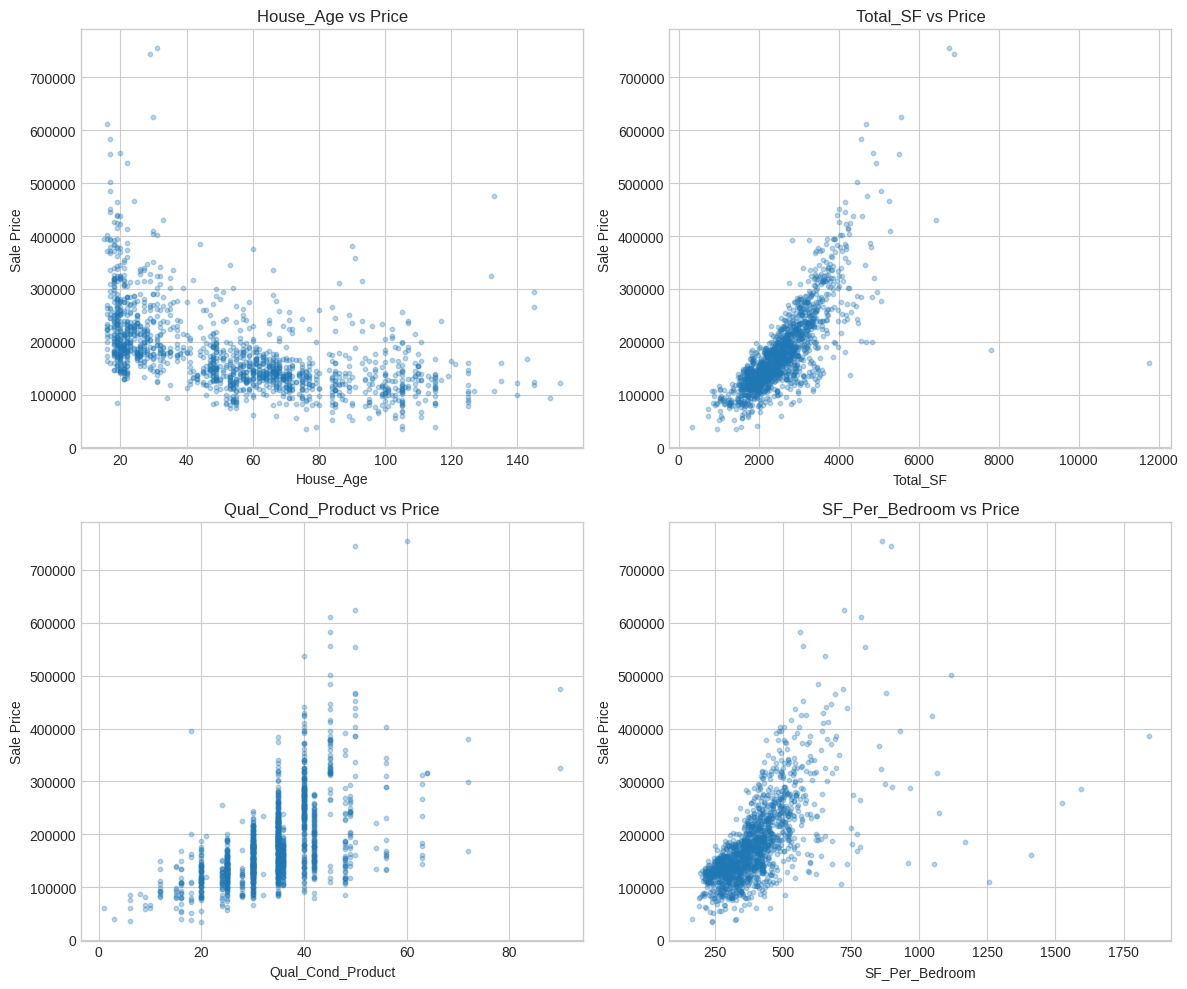

In [ ]:
# Visualize some engineered features
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_features = [f for f in ['House_Age', 'Total_SF', 'Qual_Cond_Product', 'SF_Per_Bedroom']
                 if f in df_eng.columns][:4]

for ax, feat in zip(axes.flatten(), plot_features):
    ax.scatter(df_eng[feat], df_eng[target_col], alpha=0.3, s=10)
    ax.set_xlabel(feat)
    ax.set_ylabel('Sale Price')
    ax.set_title(f'{feat} vs Price')

plt.tight_layout()
plt.show()

Binning

In [ ]:
# Connverting continous to categorical

if 'House_Age' in df_eng.columns:
  df_eng['Age_Category'] = pd.cut(df_eng['House_Age'],
                                  bins = [0, 10, 25, 50, 100, 200],
                                  labels=['New', 'Recent', 'Established', 'Old', 'Historic'])
  print("Age Category:")
  print(df_eng['Age_Category'].value_counts().sort_index())


Age Category:
Age_Category
New              0
Recent         388
Established    322
Old            604
Historic       146
Name: count, dtype: int64


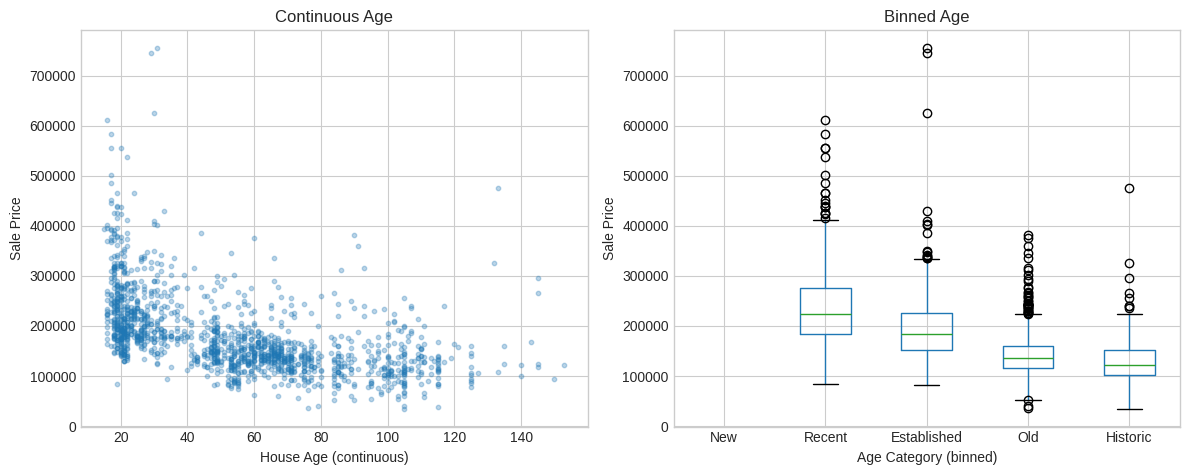

In [ ]:
if 'Age_Category' in df_eng.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Continuous
    axes[0].scatter(df_eng['House_Age'], df_eng[target_col], alpha=0.3, s=10)
    axes[0].set_xlabel('House Age (continuous)')
    axes[0].set_ylabel('Sale Price')
    axes[0].set_title('Continuous Age')

    # Binned
    df_eng.boxplot(column=target_col, by='Age_Category', ax=axes[1])
    axes[1].set_xlabel('Age Category (binned)')
    axes[1].set_ylabel('Sale Price')
    axes[1].set_title('Binned Age')
    plt.suptitle('')

    plt.tight_layout()
    plt.show()

Target Encoding

In [16]:
# Target encoding: Replace category with mean target value
#Example: Neighborhood
if 'Neighborhood' in df_eng.columns:
  neighborhood_col = 'Neighborhood'
elif 'Neighborhood' in categorical_cols:
  neighborhood_col = 'Neighborhood'
else:
  neighborhood_col = categorical_cols[0] if categorical_cols else None

if neighborhood_col:
  print(f"Target Encoding: {neighborhood_col}")
  print(f"Uniques: {df_eng[neighborhood_col].nunique()}")

  # Mean price per category
  target_means = df_eng.groupby(neighborhood_col)[target_col].mean()

  # Create encoded column
  df_eng[f'{neighborhood_col}_TargetEnc'] = df_eng[neighborhood_col].map(target_means)

  #Top/bottom
  print("Top 5:")
  print(target_means.sort_values(ascending=False).head())
  print("\nBottom 5:")
  print(target_means.sort_values(ascending=False).tail())

Target Encoding: Neighborhood
Uniques: 25
Top 5:
Neighborhood
NoRidge    335295.317073
NridgHt    316270.623377
StoneBr    310499.000000
Timber     242247.447368
Veenker    238772.727273
Name: SalePrice, dtype: float64

Bottom 5:
Neighborhood
Edwards    128219.700000
BrkSide    124834.051724
BrDale     104493.750000
IDOTRR     100123.783784
MeadowV     98576.470588
Name: SalePrice, dtype: float64


In [17]:
#Target encoding with smoothing (prevents overfitting)

def target_encode_smooth(df, cat_col, target_col, alpha=10):
  """
  Smoothed target encoding
  alpha controls blend between category mean and global mean.
  Higher alpha = more smoothing

  """
  global_mean = df[target_col].mean()
  cat_counts = df.groupby(cat_col)[target_col].count()
  cat_means = df.groupby(cat_col)[target_col].mean()

  # Smoothed encoding
  smooth_means = (cat_counts * cat_means + alpha * global_mean) / (cat_counts + alpha)

  return df[cat_col].map(smooth_means)

if neighborhood_col:
  df_eng[f'{neighborhood_col}_SmoothEnc'] = target_encode_smooth(df_eng, neighborhood_col, target_col, alpha=10)
  print('Added smoothed encoding')

Added smoothed encoding


Log transformation

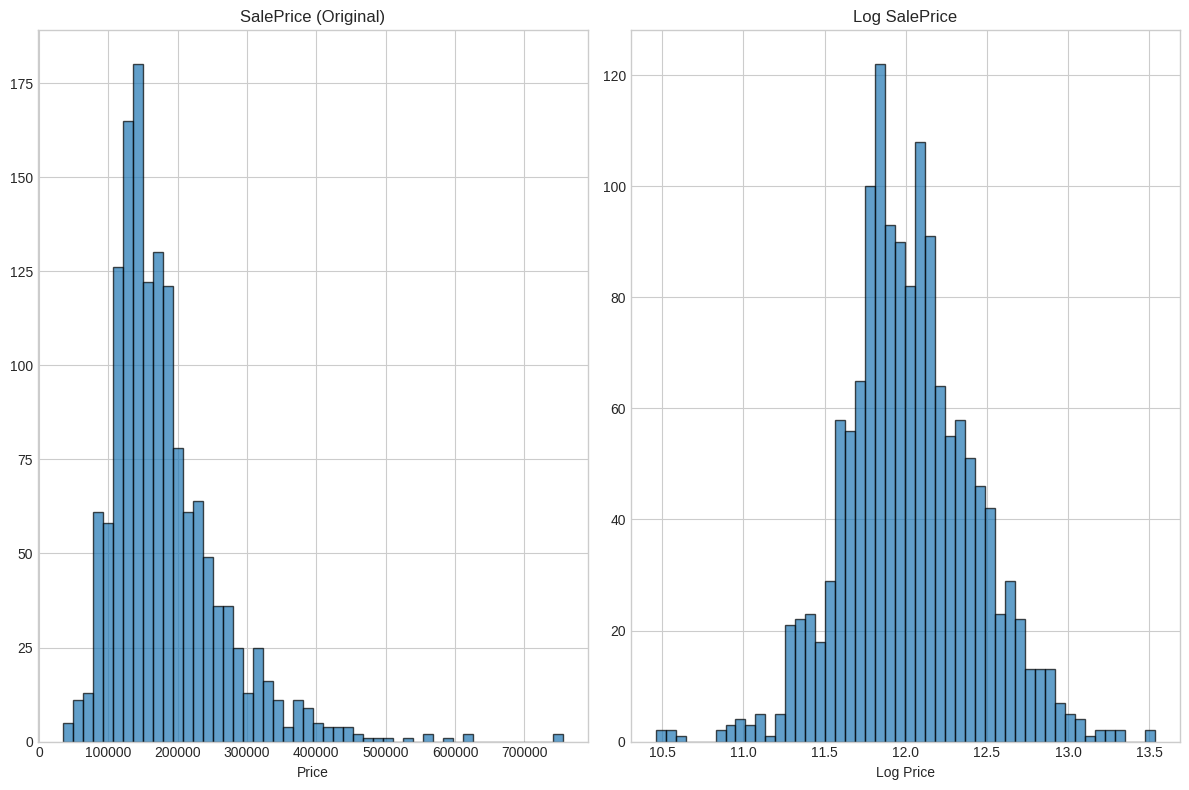

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))

axes[0].hist(df_eng[target_col], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title(f'{target_col} (Original)')
axes[0].set_xlabel('Price')

df_eng['Log_Price'] = np.log1p(df_eng[target_col])
axes[1].hist(df_eng['Log_Price'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_title(f'Log {target_col}')
axes[1].set_xlabel('Log Price')

plt.tight_layout()
plt.show()

Feature Selection

In [24]:
#Prepare numeric features for selection
numeric_features = df_eng.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_features = [f for f in numeric_features if f not in [target_col, 'Log_Price']]

x_all = df_eng[numeric_features].fillna(0)
y_all = df_eng[target_col]

print(f"Total numeric features: {len(numeric_features)}")

Total numeric features: 50


In [25]:
# Method 1: correlation based selection
correlations = x_all.corrwith(y_all).abs().sort_values(ascending=False)

print("Top 15 features by correlation:")
print(correlations.head(15).round(3))

Top 15 features by correlation:
OverallQual               0.791
Total_SF                  0.779
Neighborhood_TargetEnc    0.739
Neighborhood_SmoothEnc    0.735
GrLivArea                 0.709
GarageCars                0.640
GarageArea                0.623
SF_Per_Bedroom            0.623
TotalBsmtSF               0.614
Total_Bathrooms           0.613
1stFlrSF                  0.606
Qual_Cond_Ratio           0.595
Qual_Cond_Product         0.565
FullBath                  0.561
TotRmsAbvGrd              0.534
dtype: float64


In [26]:
#Method 2: SelectKBest
selector = SelectKBest(score_func=f_regression, k=15)
x_selected = selector.fit_transform(x_all, y_all)

selected_mask = selector.get_support()
selected_features = [f for f, s in zip(numeric_features, selected_mask) if s]

print(f"\nSelectKBest top 15 features:")
for f in selected_features:
  print(f"  .{f}")


SelectKBest top 15 features:
  .OverallQual
  .TotalBsmtSF
  .1stFlrSF
  .GrLivArea
  .FullBath
  .TotRmsAbvGrd
  .GarageCars
  .GarageArea
  .Total_SF
  .SF_Per_Bedroom
  .Qual_Cond_Ratio
  .Qual_Cond_Product
  .Total_Bathrooms
  .Neighborhood_TargetEnc
  .Neighborhood_SmoothEnc


In [28]:
#Method 3: feature importance from random forest
rf_select = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_select.fit(x_all, y_all)

importance_df = pd.DataFrame({
    'Feature': numeric_features,
    'Importance': rf_select.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop  15 by RF importance:")
print(importance_df.head(15).to_string(index=False))


Top  15 by RF importance:
               Feature  Importance
              Total_SF    0.370028
           OverallQual    0.364725
Neighborhood_TargetEnc    0.039426
Neighborhood_SmoothEnc    0.033131
              2ndFlrSF    0.025143
            BsmtFinSF1    0.013509
     Qual_Cond_Product    0.013481
        SF_Per_Bedroom    0.012069
             GrLivArea    0.010660
               LotArea    0.010435
       Total_Bathrooms    0.007868
             BsmtUnfSF    0.007213
       Qual_Cond_Ratio    0.006984
            GarageArea    0.006789
             YearBuilt    0.005002


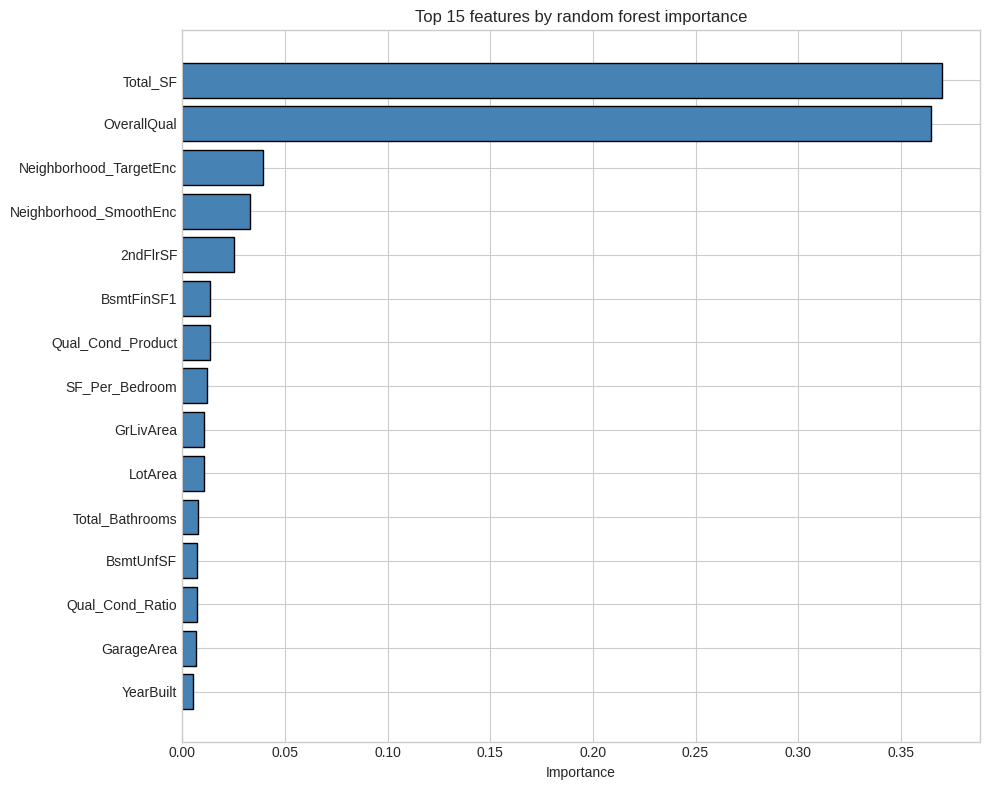

In [30]:
plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue', edgecolor='black')
plt.xlabel('Importance')
plt.title('Top 15 features by random forest importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [31]:
# Select best engineered features
top_engineered = importance_df.head(20)['Feature'].tolist()

X_engineered = df_eng[top_engineered].fillna(0)

# Train/test split (same random state)
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_engineered, y_all, test_size=0.2, random_state=42
)

# Scale
scaler_e = StandardScaler()
X_train_e_scaled = scaler_e.fit_transform(X_train_e)
X_test_e_scaled = scaler_e.transform(X_test_e)

print(f"Engineered features: {len(top_engineered)}")

Engineered features: 20


## Summary


| Technique | When to Use |
|-----------|-------------|
| Polynomial | Non-linear relationships |
| Interactions | Combined effects |
| Binning | Step-wise patterns |
| Target Encoding | High-cardinality categoricals |
| Log Transform | Skewed distributions |
| Domain Features | Expert knowledge |

### Key Takeaways

1. **Domain knowledge is gold** — understand your data
2. **Simple features often win** — ratios, ages, totals
3. **Target encoding is powerful** — but watch for leakage
4. **Feature selection matters** — remove noise
5. **Iterate** — create, test, refine

### Impact

- Feature engineering often gives 5-20% improvement
- Sometimes more valuable than model tuning
- The creative part of ML!